# Exploratory Data Analysis (EDA): Dataset Netflix Titles

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 1. Pemuatan Data & Pemeriksaan Awal

In [2]:
netflix_path = 'Data_Netflix/netflix_titles.csv'
df = pd.read_csv(netflix_path)
print(f"Shape of dataset: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Information:")
df.info()

Shape of dataset: (8807, 12)

First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA

## 2. Analisis Missing Values

In [3]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100
null_df = pd.DataFrame({'Missing Count': null_counts, 'Percentage (%)': null_pct})
print(null_df[null_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

            Missing Count  Percentage (%)
director             2634       29.908028
country               831        9.435676
cast                  825        9.367549
date_added             10        0.113546
rating                  4        0.045418
duration                3        0.034064


## 3. Distribusi Tipe Konten (Movie vs TV Show)

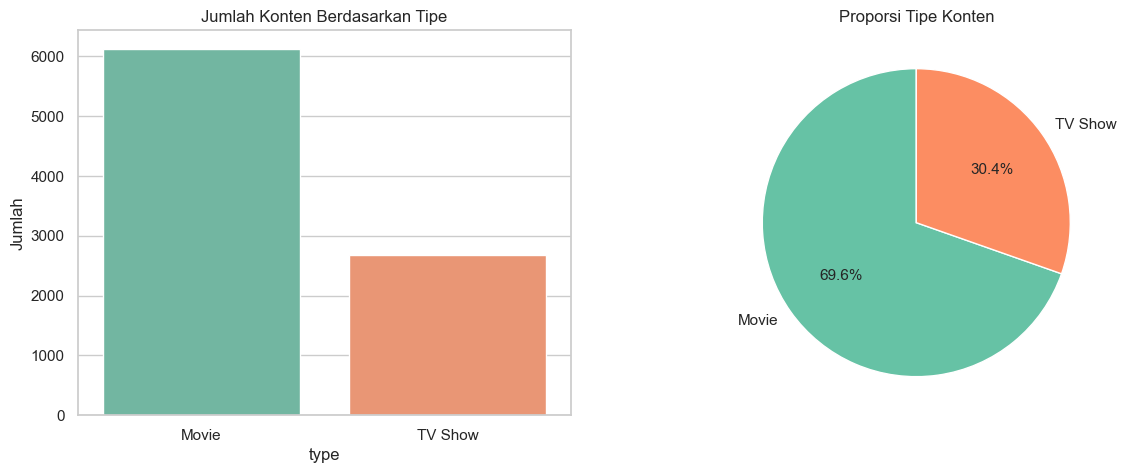

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [4]:
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
sns.barplot(x=type_counts.index, y=type_counts.values, ax=axes[0], palette='Set2')
axes[0].set_title('Jumlah Konten Berdasarkan Tipe')
axes[0].set_ylabel('Jumlah')

# Pie chart
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
axes[1].set_title('Proporsi Tipe Konten')

plt.show()
print(type_counts)

## 4. Analisis Tren Waktu (Rilis & Penambahan Konten)

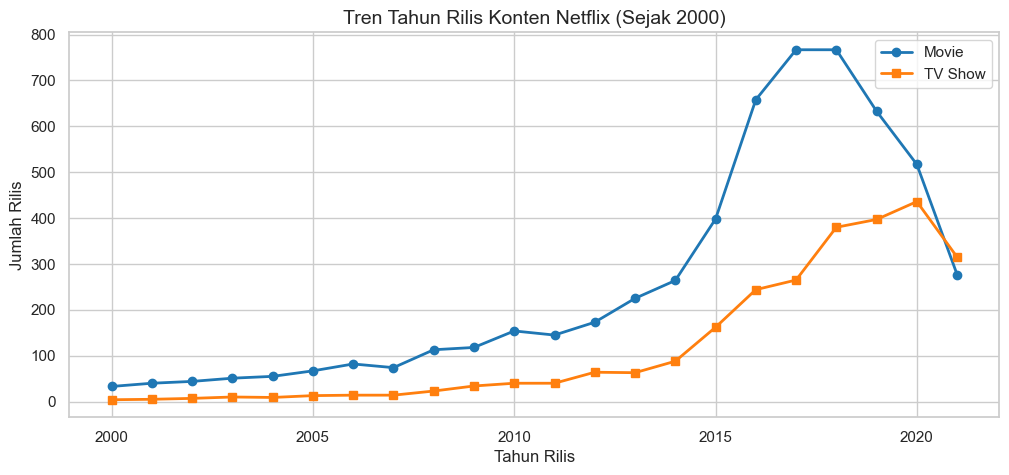

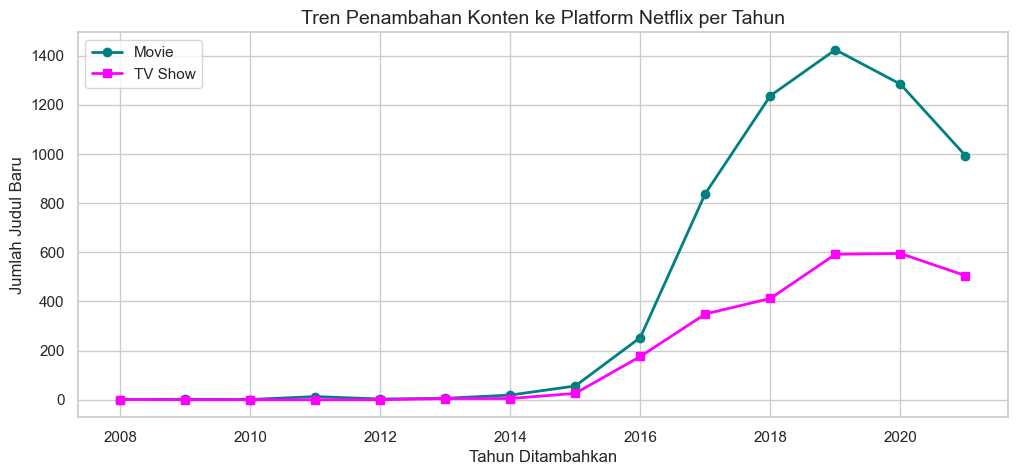

In [5]:
# Tren tahun rilis asli
release_trends = df[df['release_year'] >= 2000].groupby(['release_year', 'type']).size().unstack().fillna(0)

plt.figure(figsize=(12, 5))
plt.plot(release_trends.index, release_trends['Movie'], marker='o', label='Movie', color='#1f77b4', linewidth=2)
plt.plot(release_trends.index, release_trends['TV Show'], marker='s', label='TV Show', color='#ff7f0e', linewidth=2)
plt.title('Tren Tahun Rilis Konten Netflix (Sejak 2000)', fontsize=14)
plt.xlabel('Tahun Rilis', fontsize=12)
plt.ylabel('Jumlah Rilis', fontsize=12)
plt.legend()
plt.show()

# Tren penambahan konten ke Netflix (ekstraksi tahun dari date_added)
df['year_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce').dt.year
added_trends = df[df['year_added'] >= 2008].groupby(['year_added', 'type']).size().unstack().fillna(0)

plt.figure(figsize=(12, 5))
plt.plot(added_trends.index, added_trends['Movie'], marker='o', label='Movie', color='teal', linewidth=2)
plt.plot(added_trends.index, added_trends['TV Show'], marker='s', label='TV Show', color='magenta', linewidth=2)
plt.title('Tren Penambahan Konten ke Platform Netflix per Tahun', fontsize=14)
plt.xlabel('Tahun Ditambahkan', fontsize=12)
plt.ylabel('Jumlah Judul Baru', fontsize=12)
plt.legend()
plt.show()

## 5. Analisis Rating Umur Konten

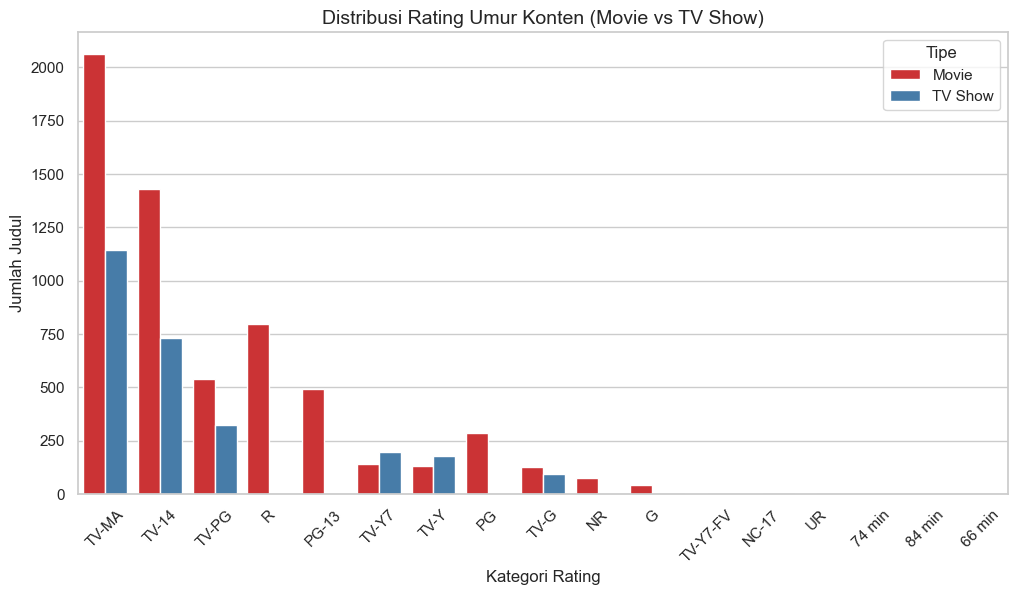

In [6]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='rating', hue='type', order=df['rating'].value_counts().index, palette='Set1')
plt.title('Distribusi Rating Umur Konten (Movie vs TV Show)', fontsize=14)
plt.xlabel('Kategori Rating', fontsize=12)
plt.ylabel('Jumlah Judul', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Tipe')
plt.show()

## 6. Analisis Durasi Konten

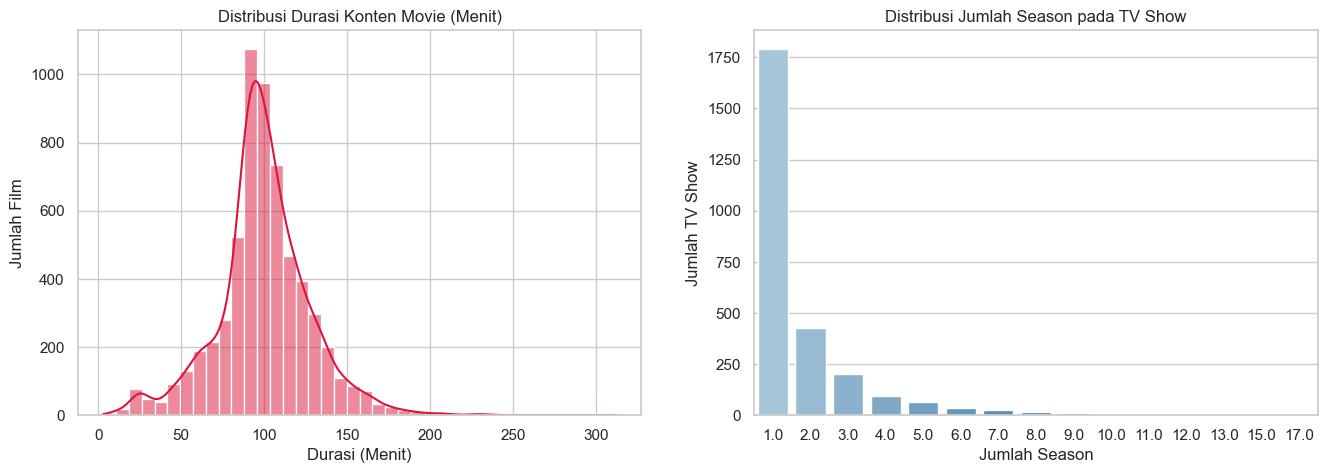

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Durasi Movie (menit)
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.replace(' min', '').astype(float)
sns.histplot(movies['duration_min'].dropna(), bins=40, kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Distribusi Durasi Konten Movie (Menit)')
axes[0].set_xlabel('Durasi (Menit)')
axes[0].set_ylabel('Jumlah Film')

# Durasi TV Show (jumlah season)
tv_shows = df[df['type'] == 'TV Show'].copy()
tv_shows['seasons'] = tv_shows['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(float)
season_counts = tv_shows['seasons'].value_counts().sort_index()
sns.barplot(x=season_counts.index, y=season_counts.values, ax=axes[1], palette='Blues_d')
axes[1].set_title('Distribusi Jumlah Season pada TV Show')
axes[1].set_xlabel('Jumlah Season')
axes[1].set_ylabel('Jumlah TV Show')

plt.show()

## 7. Analisis Elemen Multi-Nilai (Genre, Negara, Sutradara, Pemeran)

In [8]:
# Fungsi pembantu untuk memecah kolom multi-value
def explode_column(dataframe, column_name):
    return dataframe[dataframe[column_name].notnull()][column_name].str.split(', ').explode()

### Analisis Kategori/Genre

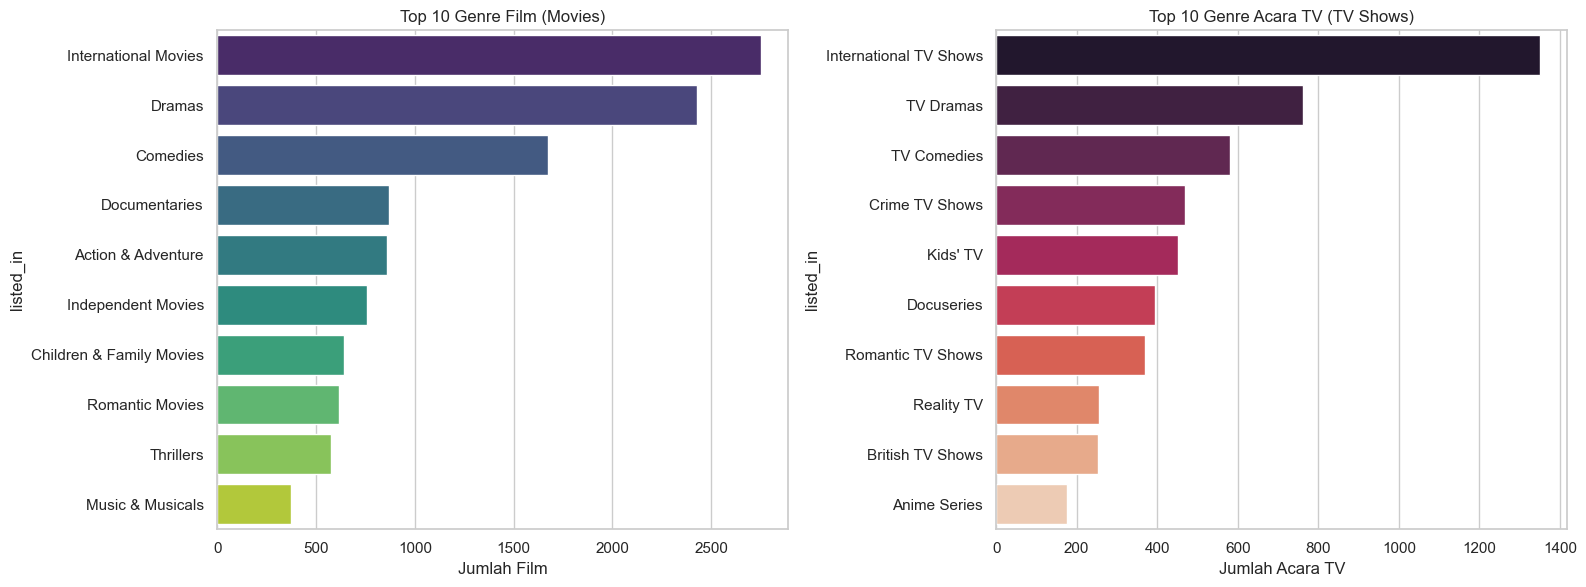

In [9]:
movie_genres = explode_column(df[df['type'] == 'Movie'], 'listed_in').value_counts().head(10)
tv_genres = explode_column(df[df['type'] == 'TV Show'], 'listed_in').value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=movie_genres.values, y=movie_genres.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Genre Film (Movies)')
axes[0].set_xlabel('Jumlah Film')

sns.barplot(x=tv_genres.values, y=tv_genres.index, ax=axes[1], palette='rocket')
axes[1].set_title('Top 10 Genre Acara TV (TV Shows)')
axes[1].set_xlabel('Jumlah Acara TV')

plt.tight_layout()
plt.show()

### Analisis Negara Asal Konten

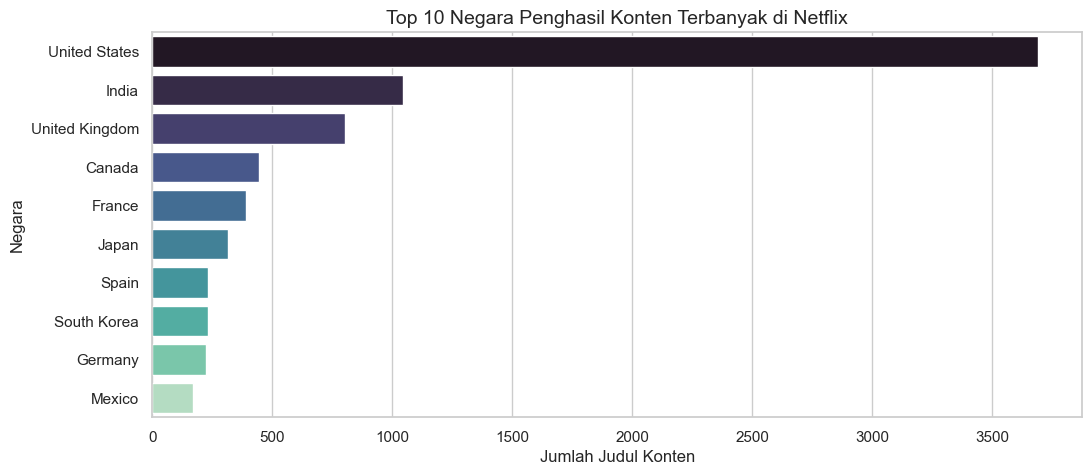

In [10]:
countries = explode_column(df, 'country').value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=countries.values, y=countries.index, palette='mako')
plt.title('Top 10 Negara Penghasil Konten Terbanyak di Netflix', fontsize=14)
plt.xlabel('Jumlah Judul Konten', fontsize=12)
plt.ylabel('Negara', fontsize=12)
plt.show()

### Analisis Sutradara & Aktor Teraktif

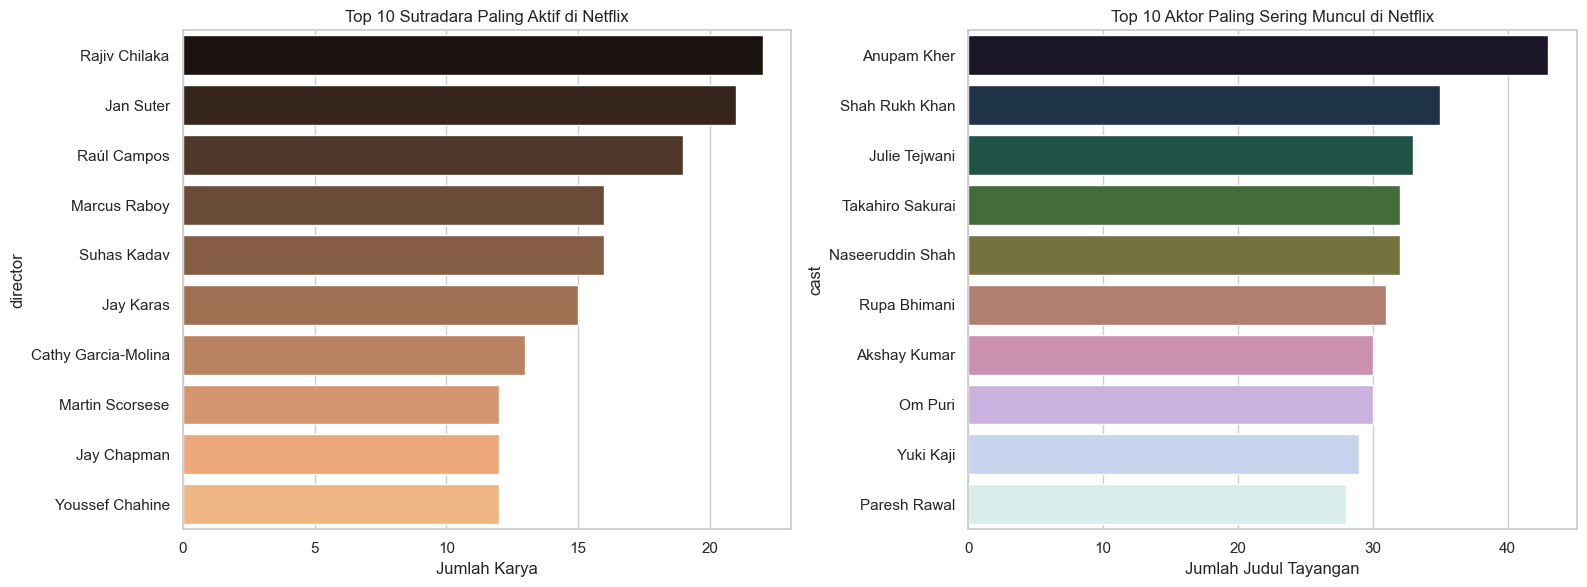

In [11]:
directors = explode_column(df, 'director').value_counts().head(10)
actors = explode_column(df, 'cast').value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=directors.values, y=directors.index, ax=axes[0], palette='copper')
axes[0].set_title('Top 10 Sutradara Paling Aktif di Netflix')
axes[0].set_xlabel('Jumlah Karya')

sns.barplot(x=actors.values, y=actors.index, ax=axes[1], palette='cubehelix')
axes[1].set_title('Top 10 Aktor Paling Sering Muncul di Netflix')
axes[1].set_xlabel('Jumlah Judul Tayangan')

plt.tight_layout()
plt.show()